# Logit-Normal Timestep Sampling Visualization

Visualize how different parameters (`mean`, `std`, `mix_ratio`) affect the training timestep `t` distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

def sample_logit_normal(n, mean, std, mix_ratio=0.0):
    u = np.random.randn(n) * std + mean
    t = 1 / (1 + np.exp(-u))  # sigmoid
    if mix_ratio > 0:
        mask = np.random.rand(n) < mix_ratio
        t[mask] = np.random.rand(mask.sum())
    return t

def logit_normal_pdf(t, mean, std):
    """Analytic logit-normal PDF."""
    u = np.log(t / (1 - t))
    return stats.norm.pdf(u, mean, std) / (t * (1 - t))

t_grid = np.linspace(1e-4, 1 - 1e-4, 500)
print("Setup done.")

Setup done.


## 1. Effect of `mean` (fixed std)

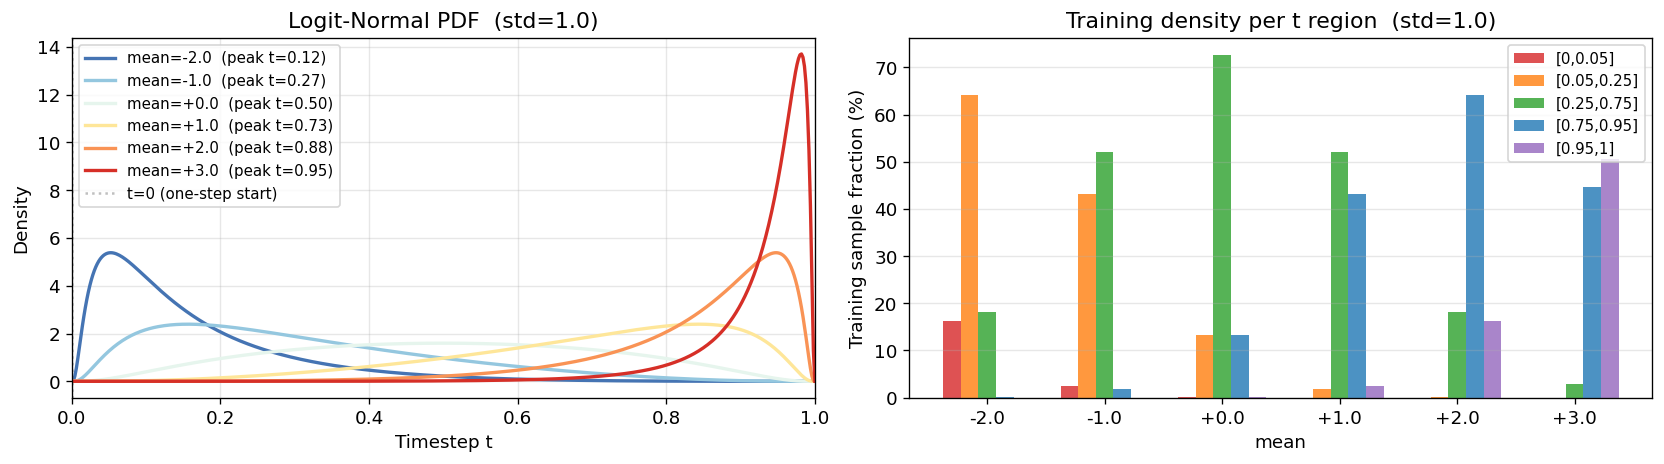

In [2]:
means = [-2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
std = 1.0
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(means)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: PDF curves
ax = axes[0]
for mean, color in zip(means, colors):
    pdf = logit_normal_pdf(t_grid, mean, std)
    peak_t = 1 / (1 + np.exp(-mean))
    ax.plot(t_grid, pdf, color=color, linewidth=2,
            label=f'mean={mean:+.1f}  (peak t={peak_t:.2f})')
ax.axvline(0.0, color='gray', linestyle=':', alpha=0.5, label='t=0 (one-step start)')
ax.set_xlabel('Timestep t')
ax.set_ylabel('Density')
ax.set_title(f'Logit-Normal PDF  (std={std})')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

# Right: training sample fraction per region for each mean
ax = axes[1]
regions = [(0, 0.05), (0.05, 0.25), (0.25, 0.75), (0.75, 0.95), (0.95, 1.0)]
region_labels = ['[0,0.05]', '[0.05,0.25]', '[0.25,0.75]', '[0.75,0.95]', '[0.95,1]']
region_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

x = np.arange(len(means))
width = 0.15
for i, ((lo, hi), label, rc) in enumerate(zip(regions, region_labels, region_colors)):
    probs = []
    for mean in means:
        pdf = logit_normal_pdf(t_grid, mean, std)
        mask = (t_grid >= lo) & (t_grid <= hi)
        prob = np.trapz(pdf[mask], t_grid[mask])
        probs.append(prob * 100)
    ax.bar(x + i * width, probs, width, label=label, color=rc, alpha=0.8)

ax.set_xlabel('mean')
ax.set_ylabel('Training sample fraction (%)')
ax.set_title(f'Training density per t region  (std={std})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f'{m:+.1f}' for m in means])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Effect of `std` (fixed mean)

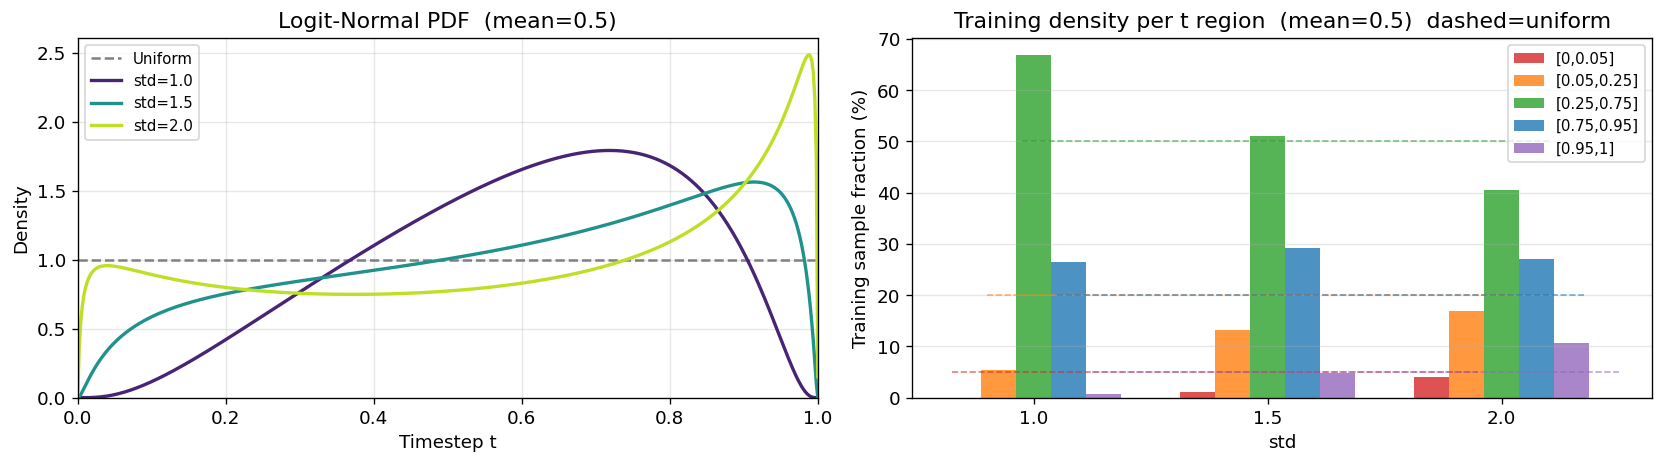

In [ ]:
mean = 0.5
stds = [0.5, 1.0, 1.5, 2.0, 3.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stds)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Uniform')
for std_val, color in zip(stds, colors):
    pdf = logit_normal_pdf(t_grid, mean, std_val)
    ax.plot(t_grid, pdf, color=color, linewidth=2, label=f'std={std_val}')
ax.set_xlabel('Timestep t')
ax.set_ylabel('Density')
ax.set_title(f'Logit-Normal PDF  (mean={mean})')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)
ax.grid(alpha=0.3)

ax = axes[1]
x = np.arange(len(stds))
for i, ((lo, hi), label, rc) in enumerate(zip(regions, region_labels, region_colors)):
    probs = []
    for std_val in stds:
        pdf = logit_normal_pdf(t_grid, mean, std_val)
        mask = (t_grid >= lo) & (t_grid <= hi)
        prob = np.trapz(pdf[mask], t_grid[mask])
        probs.append(prob * 100)
    ax.bar(x + i * width, probs, width, label=label, color=rc, alpha=0.8)

# Dashed reference lines for uniform density
uniform_probs = [(hi - lo) * 100 for lo, hi in regions]
for i, (up, rc) in enumerate(zip(uniform_probs, region_colors)):
    ax.hlines(up, x[0] + i * width - 0.05, x[-1] + i * width + width + 0.05,
              colors=rc, linestyles='dashed', linewidth=1, alpha=0.6)

ax.set_xlabel('std')
ax.set_ylabel('Training sample fraction (%)')
ax.set_title(f'Training density per t region  (mean={mean})  dashed=uniform')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([str(s) for s in stds])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Effect of `mix_ratio`: guaranteeing coverage near t=0

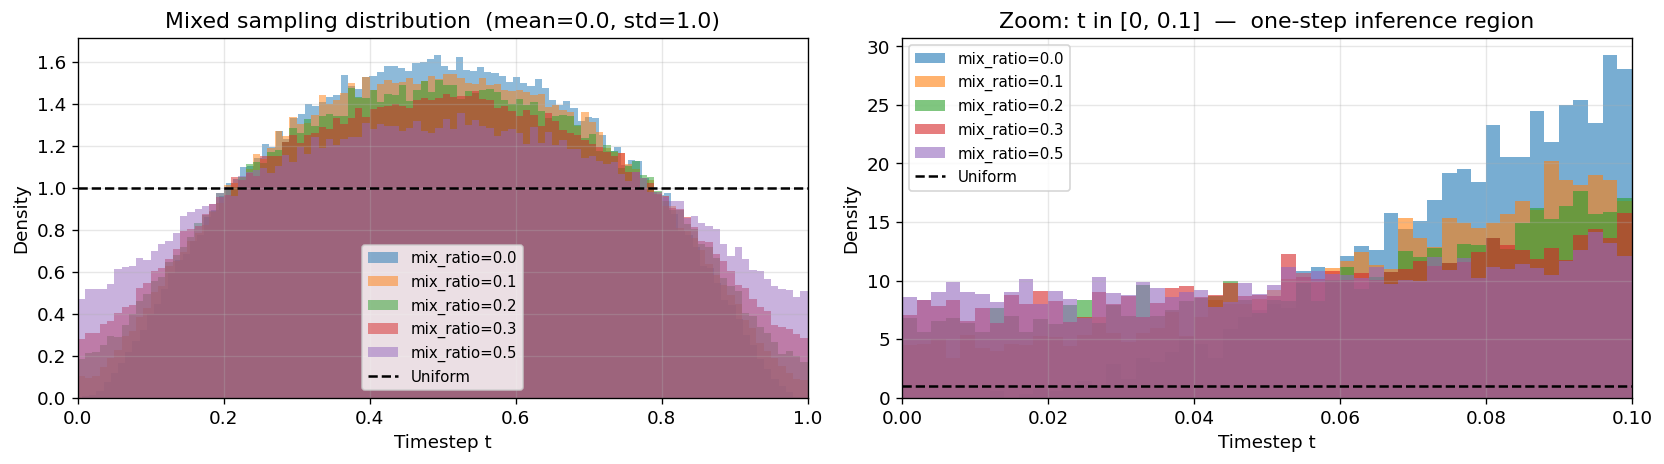

In [ ]:
mean, std = 0.5, 1.0
# mix_ratios = [0.0, 0.1, 0.2, 0.3, 0.5]
mix_ratios = [0.0, 0.1, 0.2]
N = 200_000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for mix in mix_ratios:
    t_samples = sample_logit_normal(N, mean, std, mix_ratio=mix)
    ax.hist(t_samples, bins=100, density=True, alpha=0.5,
            label=f'mix_ratio={mix}', histtype='stepfilled')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Uniform')
ax.set_xlabel('Timestep t')
ax.set_ylabel('Density')
ax.set_title(f'Mixed sampling distribution  (mean={mean}, std={std})')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

# Right: zoom into t in [0, 0.1] — one-step inference region
ax = axes[1]
for mix in mix_ratios:
    t_samples = sample_logit_normal(N, mean, std, mix_ratio=mix)
    ax.hist(t_samples, bins=50, range=(0, 0.1), density=True, alpha=0.6,
            label=f'mix_ratio={mix}', histtype='stepfilled')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Uniform')
ax.set_xlabel('Timestep t')
ax.set_ylabel('Density')
ax.set_title('Zoom: t in [0, 0.1]  —  one-step inference region')
ax.legend(fontsize=9)
ax.set_xlim(0, 0.1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Interactive parameter explorer

In [ ]:
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

def plot_distribution(mean, std, mix_ratio):
    N = 100_000
    t_samples = sample_logit_normal(N, mean, std, mix_ratio=mix_ratio)

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

    # Full distribution
    ax = axes[0]
    ax.hist(t_samples, bins=80, density=True, alpha=0.7, color='steelblue', label='samples')
    pdf = logit_normal_pdf(t_grid, mean, std)
    if mix_ratio > 0:
        pdf = (1 - mix_ratio) * pdf + mix_ratio * 1.0  # analytic mixed PDF
    ax.plot(t_grid, pdf, 'r-', linewidth=2, label='PDF')
    ax.axhline(1.0, color='gray', linestyle='--', label='Uniform')
    peak_t = 1 / (1 + np.exp(-mean))
    ax.axvline(peak_t, color='orange', linestyle=':', linewidth=1.5, label=f'peak t={peak_t:.2f}')
    ax.set_title(f'Full distribution  mean={mean}, std={std}, mix={mix_ratio}')
    ax.set_xlabel('t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Zoom t~0 (one-step region)
    ax = axes[1]
    ax.hist(t_samples[t_samples < 0.1], bins=40, density=False,
            alpha=0.7, color='tomato')
    pct_near_0 = (t_samples < 0.05).mean() * 100
    ax.set_title(f't in [0, 0.1]  —  P(t<0.05)={pct_near_0:.2f}%')
    ax.set_xlabel('t'); ax.grid(alpha=0.3)

    # Zoom t~1
    ax = axes[2]
    ax.hist(t_samples[t_samples > 0.9], bins=40, density=False,
            alpha=0.7, color='mediumseagreen')
    pct_near_1 = (t_samples > 0.95).mean() * 100
    ax.set_title(f't in [0.9, 1]  —  P(t>0.95)={pct_near_1:.2f}%')
    ax.set_xlabel('t'); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(
    plot_distribution,
    mean=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.25, description='mean'),
    std=FloatSlider(value=1.0, min=0.3, max=3.0, step=0.1, description='std'),
    mix_ratio=FloatSlider(value=0.0, min=0.0, max=0.5, step=0.05, description='mix_ratio'),
)

## 5. Reference table: training density near t=0 and t=1 across configs

In [5]:
from scipy.special import expit  # sigmoid
from scipy.stats import norm

configs = [
    dict(name='Uniform (baseline)',        mean=0.0, std=1.0, mix=0.0, use_ln=False),
    dict(name='LN mean=0, std=1',          mean=0.0, std=1.0, mix=0.0, use_ln=True),
    dict(name='LN mean=0, std=1, mix=0.2', mean=0.0, std=1.0, mix=0.2, use_ln=True),
    dict(name='LN mean=1, std=1',          mean=1.0, std=1.0, mix=0.0, use_ln=True),
    dict(name='LN mean=2, std=1',          mean=2.0, std=1.0, mix=0.0, use_ln=True),
    dict(name='LN mean=2, std=1, mix=0.2', mean=2.0, std=1.0, mix=0.2, use_ln=True),
    dict(name='LN mean=0, std=2',          mean=0.0, std=2.0, mix=0.0, use_ln=True),
]

def compute_region_prob(mean, std, mix, lo, hi):
    """Analytically compute P(lo <= t <= hi) for the mixed logit-normal distribution."""
    u_lo = np.log(lo / (1 - lo)) if lo > 0 else -np.inf
    u_hi = np.log(hi / (1 - hi)) if hi < 1 else np.inf
    p_ln = norm.cdf(u_hi, mean, std) - norm.cdf(u_lo, mean, std)
    return p_ln * (1 - mix) + (hi - lo) * mix

print(f"{'Config':<38} {'P(t<0.05)':>10} {'P(t<0.1)':>10} {'P(0.4<t<0.6)':>14} {'P(t>0.9)':>10} {'P(t>0.95)':>10}")
print('-' * 96)
for cfg in configs:
    if not cfg['use_ln']:
        p0, p1, pmid, p9, p95 = 5.0, 10.0, 20.0, 10.0, 5.0
    else:
        p0   = compute_region_prob(cfg['mean'], cfg['std'], cfg['mix'], 1e-9, 0.05) * 100
        p1   = compute_region_prob(cfg['mean'], cfg['std'], cfg['mix'], 1e-9, 0.10) * 100
        pmid = compute_region_prob(cfg['mean'], cfg['std'], cfg['mix'], 0.40, 0.60) * 100
        p9   = compute_region_prob(cfg['mean'], cfg['std'], cfg['mix'], 0.90, 1-1e-9) * 100
        p95  = compute_region_prob(cfg['mean'], cfg['std'], cfg['mix'], 0.95, 1-1e-9) * 100
    print(f"{cfg['name']:<38} {p0:>9.2f}% {p1:>9.2f}% {pmid:>13.2f}% {p9:>9.2f}% {p95:>9.2f}%")

Config                                  P(t<0.05)   P(t<0.1)   P(0.4<t<0.6)   P(t>0.9)  P(t>0.95)
------------------------------------------------------------------------------------------------
Uniform (baseline)                          5.00%     10.00%         20.00%     10.00%      5.00%
LN mean=0, std=1                            0.16%      1.40%         31.49%      1.40%      0.16%
LN mean=0, std=1, mix=0.2                   1.13%      3.12%         29.19%      3.12%      1.13%
LN mean=1, std=1                            0.00%      0.07%         19.61%     11.56%      2.59%
LN mean=2, std=1                            0.00%      0.00%          4.73%     42.18%     17.25%
LN mean=2, std=1, mix=0.2                   1.00%      2.00%          7.79%     35.75%     14.80%
LN mean=0, std=2                            7.05%     13.60%         16.07%     13.60%      7.05%
